# Bound conf 1, 2, 4

### imports

In [1]:
import pickle
import numpy as np
import MDAnalysis as mda
import matplotlib.pyplot as plt
from MDAnalysis.analysis import *
from sklearn.decomposition import PCA

/home/carolina.cretu/miniconda3/envs/MD/lib/python3.14/site-packages/MDAnalysis/analysis/hbonds/hbond_autocorrel.py:54: DeprecationWarning: This module was moved to MDAnalysis.analysis.hydrogenbonds.hbond_autocorrel; hbonds.hbond_autocorrel will be removed in 3.0.0.
  warnings.warn(wmsg, category=DeprecationWarning)
/home/carolina.cretu/miniconda3/envs/MD/lib/python3.14/site-packages/MDAnalysis/analysis/hole2/__init__.py:50: UserWarning: Please install the mdahole2 mdakit to use it in MDAnalysis.
More details can be found here: https://www.mdanalysis.org/mdahole2/getting_started.html
  warnings.warn(wmsg, category=UserWarning)
/home/carolina.cretu/miniconda3/envs/MD/lib/python3.14/site-packages/MDAnalysis/analysis/psa.py:72: UserWarning: Please install the PathSimAnalysis mdakit to use it in MDAnalysis.
More details can be found here: https://www.mdanalysis.org/PathSimAnalysis/getting_started.html
  warnings.warn(wmsg, category=UserWarning)
/home/carolina.cretu/miniconda3/envs/MD/lib/p

### Files

note: in the naming below the first number represents the conformation and the second one the run  
the letters:
h = heavy atoms, p = phosphates, c = carbon 2 

Files for bound conf 1 runs 1,2,3

In [4]:
traj_1_1 = "bound_conf_1_ligand_1_0/run_1/md05_fix_skip_5.xtc" 
top_1_1 = "bound_conf_1_ligand_1_0/run_1/md05.gro"      
ref_1_1 = "bound_conf_1_ligand_1_0/run_1/md04.gro"

traj_1_2 = "bound_conf_1_ligand_1_0/run_2/md05_fix_skip_5.xtc"
top_1_2 = "bound_conf_1_ligand_1_0/run_2/md05.gro"
ref_1_2 = "bound_conf_1_ligand_1_0/run_2/md04.gro"

traj_1_3 = "bound_conf_1_ligand_1_0/run_3/md05_fix_skip_5.xtc"
top_1_3 = "bound_conf_1_ligand_1_0/run_3/md05.gro"
ref_1_3 = "bound_conf_1_ligand_1_0/run_3/md04.gro"

Files for bound conf 2 runs 1,2,3

In [13]:
traj_2_1 = "bound_conf_2_ligand_2_9/run_1/md05_fix_skip_5.xtc" 
top_2_1 = "bound_conf_2_ligand_2_9/run_1/md05.gro"      
ref_2_1 = "bound_conf_2_ligand_2_9/run_1/md04.gro"

traj_2_2 = "bound_conf_2_ligand_2_9/run_2/md05_fix_skip_5.xtc"
top_2_2 = "bound_conf_2_ligand_2_9/run_2/md05.gro"
ref_2_2 = "bound_conf_2_ligand_2_9/run_2/md04.gro"

traj_2_3 = "bound_conf_2_ligand_2_9/run_3/md05_fix_skip_5.xtc"
top_2_3 = "bound_conf_2_ligand_2_9/run_3/md05.gro"
ref_2_3 = "bound_conf_2_ligand_2_9/run_3/md04.gro"

Files for bound conf 4 runs 1,2

In [2]:
traj_4_1 = "bound_conf_4_ligand_4_4/run_1/md05_fix_skip_5.xtc" 
top_4_1 = "bound_conf_4_ligand_4_4/run_1/md05.gro"      
ref_4_1 = "bound_conf_4_ligand_4_4/run_1/md04.gro"

traj_4_2 = "bound_conf_4_ligand_4_4/run_2/md05_fix_skip_5.xtc"
top_4_2 = "bound_conf_4_ligand_4_4/run_2/md05.gro"
ref_4_2 = "bound_conf_4_ligand_4_4/run_2/md04.gro"

traj_4_3 = "bound_conf_4_ligand_4_4/run_3/md05_fix_skip_5.xtc"
top_4_3 = "bound_conf_4_ligand_4_4/run_3/md05.gro"
ref_4_3 = "bound_conf_4_ligand_4_4/run_3/md04.gro"

### MD universes

Universe for unbounf conf 1

In [5]:
universe_1_1 = mda.Universe(top_1_1, traj_1_1)
universe_1_2 = mda.Universe(top_1_2, traj_1_2)
universe_1_3 = mda.Universe(top_1_3, traj_1_3)

Universe for unbounf conf 2

In [16]:
universe_2_1 = mda.Universe(top_2_1, traj_2_1)
universe_2_2 = mda.Universe(top_2_2, traj_2_2)
universe_2_3 = mda.Universe(top_2_3, traj_2_3)

Universe for unbounf conf 4

In [3]:
universe_4_1 = mda.Universe(top_4_1, traj_4_1)
universe_4_2 = mda.Universe(top_4_2, traj_4_2)
universe_4_3 = mda.Universe(top_4_3, traj_4_3)

### reference

In [6]:
reference = mda.Universe("bound_conf_1_ligand_1_0/run_2/md03.gro")

### Heavy atoms

##### coordinates conf 1

In [ ]:
aligner_1_1_h = align.AlignTraj(universe_1_1, reference, select='nucleic and not name H*', in_memory=True).run()

In [ ]:
aligner_1_2_h = align.AlignTraj(universe_1_2, reference, select='nucleic and not name H*', in_memory=True).run()

In [ ]:
aligner_1_3_h = align.AlignTraj(universe_1_3, reference, select='nucleic and not name H*', in_memory=True).run()

In [ ]:
selected_1_1_h = universe_1_1.select_atoms('nucleic and not name H*')
coordinates_replica_1_1_h = np.empty((len(universe_1_1.trajectory), len(selected_1_1_h.atoms), 3))

for i,ts in enumerate(universe_1_1.trajectory):
    coordinates_replica_1_1_h[i] = selected_1_1_h.positions

file_1_1_h = open('trajectory_coordinates/heavy/coordinates_replica_1_1_h.txt','wb')
pickle.dump(coordinates_replica_1_1_h,file_1_1_h)
file_1_1_h.close()

In [ ]:
selected_1_2_h = universe_1_2.select_atoms('nucleic and not name H*')
coordinates_replica_1_2_h = np.empty((len(universe_1_2.trajectory), len(selected_1_2_h.atoms), 3))

for i,ts in enumerate(universe_1_2.trajectory):
    coordinates_replica_1_2_h[i] = selected_1_2_h.positions

file_1_2_h = open('trajectory_coordinates/heavy/coordinates_replica_1_2_h.txt','wb')
pickle.dump(coordinates_replica_1_2_h,file_1_2_h)
file_1_2_h.close()

In [ ]:
selected_1_3_h = universe_1_3.select_atoms('nucleic and not name H*')
coordinates_replica_1_3_h = np.empty((len(universe_1_3.trajectory), len(selected_1_3_h.atoms), 3))

for i,ts in enumerate(universe_1_3.trajectory):
    coordinates_replica_1_3_h[i] = selected_1_3_h.positions

file_1_3_h = open('trajectory_coordinates/heavy/coordinates_replica_1_3_h.txt','wb')
pickle.dump(coordinates_replica_1_3_h,file_1_3_h)
file_1_3_h.close()    

##### coordinates conf 2

In [ ]:
aligner_2_1_h = align.AlignTraj(universe_2_1, reference, select='nucleic and not name H*', in_memory=True).run()

In [ ]:
aligner_2_2_h = align.AlignTraj(universe_2_2, reference, select='nucleic and not name H*', in_memory=True).run()

In [ ]:
aligner_2_3_h = align.AlignTraj(universe_2_3, reference, select='nucleic and not name H*', in_memory=True).run()

In [ ]:
selected_2_1_h = universe_2_1.select_atoms('nucleic and not name H*')
coordinates_replica_2_1_h = np.empty((len(universe_2_1.trajectory), len(selected_2_1_h.atoms), 3))

for i,ts in enumerate(universe_2_1.trajectory):
    coordinates_replica_2_1_h[i] = selected_2_1_h.positions

file_2_1_h = open('trajectory_coordinates/heavy/coordinates_replica_2_1_h.txt','wb')
pickle.dump(coordinates_replica_2_1_h,file_2_1_h)
file_2_1_h.close()    

In [ ]:
selected_2_2_h = universe_2_2.select_atoms('nucleic and not name H*')
coordinates_replica_2_2_h = np.empty((len(universe_2_2.trajectory), len(selected_2_2_h.atoms), 3))

for i,ts in enumerate(universe_2_2.trajectory):
    coordinates_replica_2_2_h[i] = selected_2_2_h.positions

file_2_2_h = open('trajectory_coordinates/heavy/coordinates_replica_2_2_h.txt','wb')
pickle.dump(coordinates_replica_2_2_h,file_2_2_h)
file_2_2_h.close()    

In [ ]:
selected_2_3_h = universe_2_3.select_atoms('nucleic and not name H*')
coordinates_replica_2_3_h = np.empty((len(universe_2_3.trajectory), len(selected_2_3_h.atoms), 3))

for i,ts in enumerate(universe_2_3.trajectory):
    coordinates_replica_2_3_h[i] = selected_2_3_h.positions

file_2_3_h = open('trajectory_coordinates/heavy/coordinates_replica_2_3_h.txt','wb')
pickle.dump(coordinates_replica_2_3_h,file_2_3_h)
file_2_3_h.close()    

##### coordinates conf 4

In [ ]:
aligner_4_1_h = align.AlignTraj(universe_4_1, reference, select='nucleic and not name H*', in_memory=True).run()

In [ ]:
aligner_4_2_h = align.AlignTraj(universe_4_2, reference, select='nucleic and not name H*', in_memory=True).run()

In [ ]:
aligner_4_3_h = align.AlignTraj(universe_4_3, reference, select='nucleic and not name H*', in_memory=True).run()

In [ ]:
selected_4_1_h = universe_4_1.select_atoms('nucleic and not name H*')
coordinates_replica_4_1_h = np.empty((len(universe_4_1.trajectory), len(selected_4_1_h.atoms), 3))

for i,ts in enumerate(universe_4_1.trajectory):
    coordinates_replica_4_1_h[i] = selected_4_1_h.positions

file_4_1_h = open('trajectory_coordinates/heavy/coordinates_replica_4_1_h.txt','wb')
pickle.dump(coordinates_replica_4_1_h,file_4_1_h)
file_4_1_h.close()     

In [ ]:
selected_4_2_h = universe_4_2.select_atoms('nucleic and not name H*')
coordinates_replica_4_2_h = np.empty((len(universe_4_2.trajectory), len(selected_4_2_h.atoms), 3))

for i,ts in enumerate(universe_4_2.trajectory):
    coordinates_replica_4_2_h[i] = selected_4_2_h.positions

file_4_2_h = open('trajectory_coordinates/heavy/coordinates_replica_4_2_h.txt','wb')
pickle.dump(coordinates_replica_4_2_h,file_4_2_h)
file_4_2_h.close()     

In [ ]:
selected_4_3_h = universe_4_3.select_atoms('nucleic and not name H*')
coordinates_replica_4_3_h = np.empty((len(universe_4_3.trajectory), len(selected_4_3_h.atoms), 3))

for i,ts in enumerate(universe_4_3.trajectory):
    coordinates_replica_4_3_h[i] = selected_4_3_h.positions

file_4_3_h = open('trajectory_coordinates/heavy/coordinates_replica_4_3_h.txt','wb')
pickle.dump(coordinates_replica_4_3_h,file_4_3_h)
file_4_3_h.close()     

##### PCA

In [ ]:
file_1_1_h = open('trajectory_coordinates/heavy/coordinates_replica_1_1_h.txt','rb')
coordinates_replica_1_1_h = pickle.load(file_1_1_h)

file_1_2_h = open('trajectory_coordinates/heavy/coordinates_replica_1_2_h.txt','rb')
coordinates_replica_1_2_h = pickle.load(file_1_2_h)

file_1_3_h = open('trajectory_coordinates/heavy/coordinates_replica_1_3_h.txt','rb')
coordinates_replica_1_3_h = pickle.load(file_1_3_h)

In [ ]:
file_2_1_h = open('trajectory_coordinates/heavy/coordinates_replica_2_1_h.txt','rb')
coordinates_replica_2_1_h = pickle.load(file_2_1_h)

file_2_2_h = open('trajectory_coordinates/heavy/coordinates_replica_2_2_h.txt','rb')
coordinates_replica_2_2_h = pickle.load(file_2_2_h)

file_2_3_h = open('trajectory_coordinates/heavy/coordinates_replica_2_3_h.txt','rb')
coordinates_replica_2_3_h = pickle.load(file_2_3_h)

In [ ]:
file_4_1_h = open('trajectory_coordinates/heavy/coordinates_replica_4_1_h.txt','rb')
coordinates_replica_4_1_h = pickle.load(file_4_1_h)

file_4_2_h = open('trajectory_coordinates/heavy/coordinates_replica_4_2_h.txt','rb')
coordinates_replica_4_2_h = pickle.load(file_4_2_h)

file_4_3_h = open('trajectory_coordinates/heavy/coordinates_replica_4_3_h.txt','rb')
coordinates_replica_4_3_h = pickle.load(file_4_3_h)

In [ ]:
coordinates_h = np.concatenate([coordinates_replica_1_1_h,coordinates_replica_1_2_h,coordinates_replica_1_3_h,
                            coordinates_replica_2_1_h,coordinates_replica_2_2_h, coordinates_replica_2_3_h,
                            coordinates_replica_4_1_h,coordinates_replica_4_2_h,coordinates_replica_4_3_h])

In [ ]:
coordinates_h.shape

In [ ]:
pca_h = PCA(n_components=3)

In [ ]:
dim_red_h = pca_h.fit_transform(coordinates_h.reshape(18009,-1))

#### plot

In [ ]:
plt.style.use('_mpl-gallery')
plt.figure(figsize=(8,7))
plt.scatter(dim_red_h[:2001,0],dim_red_h[:2001,1], s=10, color="lightcoral")
plt.scatter(dim_red_h[2001:4002,0],dim_red_h[2001:4002,1], s=10, color="indianred")
plt.scatter(dim_red_h[4002:6003,0],dim_red_h[4002:6003,1], s=10, color="brown")
plt.scatter(dim_red_h[6003:8004,0],dim_red_h[6003:8004,1], s=10, color="lightskyblue")
plt.scatter(dim_red_h[8004:10005,0],dim_red_h[8004:10005,1], s=10, color="deepskyblue")
plt.scatter(dim_red_h[10005:12006,0],dim_red_h[10005:12006,1], s=10, color="steelblue")
plt.scatter(dim_red_h[12006:14007,0],dim_red_h[12006:14007,1], s=10, color="mediumpurple")
plt.scatter(dim_red_h[14007:,0],dim_red_h[14007:,1], s=10, color="blueviolet")
plt.scatter(dim_red_h[16008:,0],dim_red_h[16008:,1], s=10, color="rebeccapurple")

plt.legend(['conf 1 run 1','conf 1 run 2', 'conf 1 run 3',
            'conf 2 run 1','conf 2 run 2', 'conf 2 run 3',
            'conf 4 run 1','conf 4 run 2', 'conf 4 run 3'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of unbound conformations with heavy atoms taken as reference')
plt.show()

### Phosphates

#### coordinates conf 1

In [ ]:
aligner_1_1_p = align.AlignTraj(universe_1_1, reference, select='name P', in_memory=True).run()

In [ ]:
aligner_1_2_p = align.AlignTraj(universe_1_2, reference, select='name P', in_memory=True).run()

In [ ]:
aligner_1_3_p = align.AlignTraj(universe_1_3, reference, select='name P', in_memory=True).run()

In [ ]:
selected_1_1_p = universe_1_1.select_atoms('name P')
coordinates_replica_1_1_p = np.empty((len(universe_1_1.trajectory), len(selected_1_1_p.atoms), 3))

for i,ts in enumerate(universe_1_1.trajectory):
    coordinates_replica_1_1_p[i] = selected_1_1_p.positions

file_1_1_p = open('trajectory_coordinates/p/coordinates_replica_1_1_p.txt','wb')
pickle.dump(coordinates_replica_1_1_p,file_1_1_p)
file_1_1_p.close()

In [ ]:
selected_1_2_p = universe_1_2.select_atoms('name P')
coordinates_replica_1_2_p = np.empty((len(universe_1_2.trajectory), len(selected_1_2_p.atoms), 3))

for i,ts in enumerate(universe_1_2.trajectory):
    coordinates_replica_1_2_p[i] = selected_1_2_p.positions

file_1_2_p = open('trajectory_coordinates/p/coordinates_replica_1_2_p.txt','wb')
pickle.dump(coordinates_replica_1_2_p,file_1_2_p)
file_1_2_p.close()

In [ ]:
selected_1_3_p = universe_1_3.select_atoms('name P')
coordinates_replica_1_3_p = np.empty((len(universe_1_3.trajectory), len(selected_1_3_p.atoms), 3))

for i,ts in enumerate(universe_1_3.trajectory):
    coordinates_replica_1_3_p[i] = selected_1_3_p.positions

file_1_3_p = open('trajectory_coordinates/p/coordinates_replica_1_3_p.txt','wb')
pickle.dump(coordinates_replica_1_3_p,file_1_3_p)
file_1_3_p.close()    

#### coordinates conf 2

In [ ]:
aligner_2_1_p = align.AlignTraj(universe_2_1, reference, select='name P', in_memory=True).run()

In [ ]:
aligner_2_2_p = align.AlignTraj(universe_2_2, reference, select='name P', in_memory=True).run()

In [ ]:
aligner_2_3_p = align.AlignTraj(universe_2_3, reference, select='name P', in_memory=True).run()

In [ ]:
selected_2_1_p = universe_2_1.select_atoms('name P')
coordinates_replica_2_1_p = np.empty((len(universe_2_1.trajectory), len(selected_2_1_p.atoms), 3))

for i,ts in enumerate(universe_2_1.trajectory):
    coordinates_replica_2_1_p[i] = selected_2_1_p.positions

file_2_1_p = open('trajectory_coordinates/p/coordinates_replica_2_1_p.txt','wb')
pickle.dump(coordinates_replica_2_1_p,file_2_1_p)
file_2_1_p.close()

In [ ]:
selected_2_2_p = universe_2_2.select_atoms('name P')
coordinates_replica_2_2_p = np.empty((len(universe_2_2.trajectory), len(selected_2_2_p.atoms), 3))

for i,ts in enumerate(universe_2_2.trajectory):
    coordinates_replica_2_2_p[i] = selected_2_2_p.positions

file_2_2_p = open('trajectory_coordinates/p/coordinates_replica_2_2_p.txt','wb')
pickle.dump(coordinates_replica_2_2_p,file_2_2_p)
file_2_2_p.close()        

In [ ]:
selected_2_3_p = universe_2_3.select_atoms('name P')
coordinates_replica_2_3_p = np.empty((len(universe_2_3.trajectory), len(selected_2_3_p.atoms), 3))

for i,ts in enumerate(universe_2_3.trajectory):
    coordinates_replica_2_3_p[i] = selected_2_3_p.positions

file_2_3_p = open('trajectory_coordinates/p/coordinates_replica_2_3_p.txt','wb')
pickle.dump(coordinates_replica_2_3_p,file_2_3_p)
file_2_3_p.close()        

#### coordinates conf 4

In [ ]:
aligner_4_1_p = align.AlignTraj(universe_4_1, reference, select='name P', in_memory=True).run()

In [ ]:
aligner_4_2_p = align.AlignTraj(universe_4_2, reference, select='name P', in_memory=True).run()

In [ ]:
aligner_4_3_p = align.AlignTraj(universe_4_3, reference, select='name P', in_memory=True).run()

In [ ]:
selected_4_1_p = universe_4_1.select_atoms('name P')
coordinates_replica_4_1_p = np.empty((len(universe_4_1.trajectory), len(selected_4_1_p.atoms), 3))

for i,ts in enumerate(universe_4_1.trajectory):
    coordinates_replica_4_1_p[i] = selected_4_1_p.positions

file_4_1_p = open('trajectory_coordinates/p/coordinates_replica_4_1_p.txt','wb')
pickle.dump(coordinates_replica_4_1_p,file_4_1_p)
file_4_1_p.close()    

In [ ]:
selected_4_2_p = universe_4_2.select_atoms('name P')
coordinates_replica_4_2_p = np.empty((len(universe_4_2.trajectory), len(selected_4_2_p.atoms), 3))

for i,ts in enumerate(universe_4_2.trajectory):
    coordinates_replica_4_2_p[i] = selected_4_2_p.positions

file_4_2_p = open('trajectory_coordinates/p/coordinates_replica_4_2_p.txt','wb')
pickle.dump(coordinates_replica_4_2_p,file_4_2_p)
file_4_2_p.close()       

In [ ]:
selected_4_3_p = universe_4_3.select_atoms('name P')
coordinates_replica_4_3_p = np.empty((len(universe_4_3.trajectory), len(selected_4_3_p.atoms), 3))

for i,ts in enumerate(universe_4_3.trajectory):
    coordinates_replica_4_3_p[i] = selected_4_3_p.positions

file_4_3_p = open('trajectory_coordinates/p/coordinates_replica_4_3_p.txt','wb')
pickle.dump(coordinates_replica_4_3_p,file_4_3_p)
file_4_3_p.close()       

#### PCA

In [ ]:
file_1_1_p = open('trajectory_coordinates/p/coordinates_replica_1_1_p.txt','rb')
coordinates_replica_1_1_p = pickle.load(file_1_1_p)

file_1_2_p = open('trajectory_coordinates/p/coordinates_replica_1_2_p.txt','rb')
coordinates_replica_1_2_p = pickle.load(file_1_2_p)

file_1_3_p = open('trajectory_coordinates/p/coordinates_replica_1_3_p.txt','rb')
coordinates_replica_1_3_p = pickle.load(file_1_3_p)

In [ ]:
file_2_1_p = open('trajectory_coordinates/p/coordinates_replica_2_1_p.txt','rb')
coordinates_replica_2_1_p = pickle.load(file_2_1_p)

file_2_2_p = open('trajectory_coordinates/p/coordinates_replica_2_2_p.txt','rb')
coordinates_replica_2_2_p = pickle.load(file_2_2_p)

file_2_3_p = open('trajectory_coordinates/p/coordinates_replica_2_3_p.txt','rb')
coordinates_replica_2_3_p = pickle.load(file_2_3_p)

In [ ]:
file_4_1_p = open('trajectory_coordinates/p/coordinates_replica_4_1_p.txt','rb')
coordinates_replica_4_1_p = pickle.load(file_4_1_p)

file_4_2_p = open('trajectory_coordinates/p/coordinates_replica_4_2_p.txt','rb')
coordinates_replica_4_2_p = pickle.load(file_4_2_p)

file_4_3_p = open('trajectory_coordinates/p/coordinates_replica_4_3_p.txt','rb')
coordinates_replica_4_3_p = pickle.load(file_4_3_p)

In [ ]:
coordinates_p = np.concatenate([coordinates_replica_1_1_p,coordinates_replica_1_2_p,coordinates_replica_1_3_p,
                            coordinates_replica_2_1_p,coordinates_replica_2_2_p, coordinates_replica_2_3_p,
                            coordinates_replica_4_1_p,coordinates_replica_4_2_p,coordinates_replica_4_3_p])

In [ ]:
coordinates_p.shape

pca

In [ ]:
pca_p = PCA(n_components=3)

In [ ]:
dim_red_p = pca_p.fit_transform(coordinates_p.reshape(18009,-1))

#### plot

In [ ]:
plt.style.use('_mpl-gallery')
plt.figure(figsize=(8,7))
plt.scatter(dim_red_p[:2001,0],dim_red_p[:2001,1], s=10, color="lightcoral")
plt.scatter(dim_red_p[2001:4002,0],dim_red_p[2001:4002,1], s=10, color="indianred")
plt.scatter(dim_red_p[4002:6003,0],dim_red_p[4002:6003,1], s=10, color="brown")
plt.scatter(dim_red_p[6003:8004,0],dim_red_p[6003:8004,1], s=10, color="lightskyblue")
plt.scatter(dim_red_p[8004:10005,0],dim_red_p[8004:10005,1], s=10, color="deepskyblue")
plt.scatter(dim_red_p[10005:12006,0],dim_red_p[10005:12006,1], s=10, color="steelblue")
plt.scatter(dim_red_p[12006:14007,0],dim_red_p[12006:14007,1], s=10, color="mediumpurple")
plt.scatter(dim_red_p[14007:,0],dim_red_p[14007:,1], s=10, color="blueviolet")
plt.scatter(dim_red_p[16008:,0],dim_red_p[16008:,1], s=10, color="rebeccapurple")

plt.legend(['conf 1 run 1','conf 1 run 2', 'conf 1 run 3',
            'conf 2 run 1','conf 2 run 2', 'conf 2 run 3',
            'conf 4 run 1','conf 4 run 2', 'conf 4 run 3'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of unbound conformations with phosphates taken as reference')
plt.show()

### C2 - use this one

#### coordinates conf 1

In [19]:
aligner_1_1_c = align.AlignTraj(universe_1_1, reference, select='name C2', in_memory=True).run()

In [20]:
aligner_1_2_c = align.AlignTraj(universe_1_2, reference, select='name C2', in_memory=True).run()

In [21]:
aligner_1_3_c = align.AlignTraj(universe_1_3, reference, select='name C2', in_memory=True).run()

In [22]:
selected_1_1_c = universe_1_1.select_atoms('name C2 and nucleic')
coordinates_replica_1_1_c = np.empty((len(universe_1_1.trajectory), len(selected_1_1_c.atoms), 3))

for i,ts in enumerate(universe_1_1.trajectory):
    coordinates_replica_1_1_c[i] = selected_1_1_c.positions

file_1_1_c = open('trajectory_coordinates/c2/coordinates_replica_1_1_c.txt','wb')
pickle.dump(coordinates_replica_1_1_c,file_1_1_c)
file_1_1_c.close()    

In [23]:
selected_1_2_c = universe_1_2.select_atoms('name C2 and nucleic')
coordinates_replica_1_2_c = np.empty((len(universe_1_2.trajectory), len(selected_1_2_c.atoms), 3))

for i,ts in enumerate(universe_1_2.trajectory):
    coordinates_replica_1_2_c[i] = selected_1_2_c.positions

file_1_2_c = open('trajectory_coordinates/c2/coordinates_replica_1_2_c.txt','wb')
pickle.dump(coordinates_replica_1_2_c,file_1_2_c)
file_1_2_c.close()     

In [24]:
selected_1_3_c = universe_1_3.select_atoms('name C2 and nucleic')
coordinates_replica_1_3_c = np.empty((len(universe_1_3.trajectory), len(selected_1_3_c.atoms), 3))

for i,ts in enumerate(universe_1_3.trajectory):
    coordinates_replica_1_3_c[i] = selected_1_3_c.positions

file_1_3_c = open('trajectory_coordinates/c2/coordinates_replica_1_3_c.txt','wb')
pickle.dump(coordinates_replica_1_3_c,file_1_3_c)
file_1_3_c.close()     

#### coordinates conf 2

In [25]:
aligner_2_1_c = align.AlignTraj(universe_2_1, reference, select='name C2', in_memory=True).run()

In [26]:
aligner_2_2_c = align.AlignTraj(universe_2_2, reference, select='name C2', in_memory=True).run()

In [27]:
aligner_2_3_c = align.AlignTraj(universe_2_3, reference, select='name C2', in_memory=True).run()

In [28]:
selected_2_1_c = universe_2_1.select_atoms('name C2 and nucleic')
coordinates_replica_2_1_c = np.empty((len(universe_2_1.trajectory), len(selected_2_1_c.atoms), 3))

for i,ts in enumerate(universe_2_1.trajectory):
    coordinates_replica_2_1_c[i] = selected_2_1_c.positions

file_2_1_c = open('trajectory_coordinates/c2/coordinates_replica_2_1_c.txt','wb')
pickle.dump(coordinates_replica_2_1_c,file_2_1_c)
file_2_1_c.close()    

In [29]:
selected_2_2_c = universe_2_2.select_atoms('name C2 and nucleic')
coordinates_replica_2_2_c = np.empty((len(universe_2_2.trajectory), len(selected_2_2_c.atoms), 3))

for i,ts in enumerate(universe_2_2.trajectory):
    coordinates_replica_2_2_c[i] = selected_2_2_c.positions

file_2_2_c = open('trajectory_coordinates/c2/coordinates_replica_2_2_c.txt','wb')
pickle.dump(coordinates_replica_2_2_c,file_2_2_c)
file_2_2_c.close()      

In [30]:
selected_2_3_c = universe_2_3.select_atoms('name C2 and nucleic')
coordinates_replica_2_3_c = np.empty((len(universe_2_3.trajectory), len(selected_2_3_c.atoms), 3))

for i,ts in enumerate(universe_2_3.trajectory):
    coordinates_replica_2_3_c[i] = selected_2_3_c.positions

file_2_3_c = open('trajectory_coordinates/c2/coordinates_replica_2_3_c.txt','wb')
pickle.dump(coordinates_replica_2_3_c,file_2_3_c)
file_2_3_c.close()      

#### coordinates conf 4

In [31]:
aligner_4_1_c = align.AlignTraj(universe_4_1, reference, select='name C2', in_memory=True).run()

In [7]:
aligner_4_2_c = align.AlignTraj(universe_4_2, reference, select='name C2', in_memory=True).run()

In [9]:
aligner_4_3_c = align.AlignTraj(universe_4_3, reference, select='name C2', in_memory=True).run()

In [32]:
selected_4_1_c = universe_4_1.select_atoms('name C2 and nucleic')
coordinates_replica_4_1_c = np.empty((len(universe_4_1.trajectory), len(selected_4_1_c.atoms), 3))

for i,ts in enumerate(universe_4_1.trajectory):
    coordinates_replica_4_1_c[i] = selected_4_1_c.positions

file_4_1_c = open('trajectory_coordinates/c2/coordinates_replica_4_1_c.txt','wb')
pickle.dump(coordinates_replica_4_1_c,file_4_1_c)
file_4_1_c.close()       

In [8]:
selected_4_2_c = universe_4_2.select_atoms('name C2 and nucleic')
coordinates_replica_4_2_c = np.empty((len(universe_4_2.trajectory), len(selected_4_2_c.atoms), 3))

for i,ts in enumerate(universe_4_2.trajectory):
    coordinates_replica_4_2_c[i] = selected_4_2_c.positions

file_4_2_c = open('trajectory_coordinates/c2/coordinates_replica_4_2_c.txt','wb')
pickle.dump(coordinates_replica_4_2_c,file_4_2_c)
file_4_2_c.close()      

In [10]:
selected_4_3_c = universe_4_3.select_atoms('name C2 and nucleic')
coordinates_replica_4_3_c = np.empty((len(universe_4_3.trajectory), len(selected_4_3_c.atoms), 3))

for i,ts in enumerate(universe_4_3.trajectory):
    coordinates_replica_4_3_c[i] = selected_4_3_c.positions

file_4_3_c = open('trajectory_coordinates/c2/coordinates_replica_4_3_c.txt','wb')
pickle.dump(coordinates_replica_4_3_c,file_4_3_c)
file_4_3_c.close()      

#### PCA

In [11]:
file_1_1_c = open('trajectory_coordinates/c2/coordinates_replica_1_1_c.txt','rb')
coordinates_replica_1_1_c = pickle.load(file_1_1_c)

file_1_2_c = open('trajectory_coordinates/c2/coordinates_replica_1_2_c.txt','rb')
coordinates_replica_1_2_c = pickle.load(file_1_2_c)

file_1_3_c = open('trajectory_coordinates/c2/coordinates_replica_1_3_c.txt','rb')
coordinates_replica_1_3_c = pickle.load(file_1_3_c)

In [12]:
file_2_1_c = open('trajectory_coordinates/c2/coordinates_replica_2_1_c.txt','rb')
coordinates_replica_2_1_c = pickle.load(file_2_1_c)

file_2_2_c = open('trajectory_coordinates/c2/coordinates_replica_2_2_c.txt','rb')
coordinates_replica_2_2_c = pickle.load(file_2_2_c)

file_2_3_c = open('trajectory_coordinates/c2/coordinates_replica_2_3_c.txt','rb')
coordinates_replica_2_3_c = pickle.load(file_2_3_c)

In [13]:
file_4_1_c = open('trajectory_coordinates/c2/coordinates_replica_4_1_c.txt','rb')
coordinates_replica_4_1_c = pickle.load(file_4_1_c)

file_4_2_c = open('trajectory_coordinates/c2/coordinates_replica_4_2_c.txt','rb')
coordinates_replica_4_2_c = pickle.load(file_4_2_c)

file_4_3_c = open('trajectory_coordinates/c2/coordinates_replica_4_3_c.txt','rb')
coordinates_replica_4_3_c = pickle.load(file_4_3_c)

In [14]:
coordinates_c = np.concatenate([coordinates_replica_1_1_c,coordinates_replica_1_2_c,coordinates_replica_1_3_c,
                            coordinates_replica_2_1_c,coordinates_replica_2_2_c, coordinates_replica_2_3_c,
                            coordinates_replica_4_1_c,coordinates_replica_4_2_c,coordinates_replica_4_3_c])

In [15]:
coordinates_c.shape

(18009, 74, 3)

In [16]:
pca_c = PCA(n_components=3)

In [17]:
dim_red_c = pca_c.fit_transform(coordinates_c.reshape(18009,-1))

 #### plot

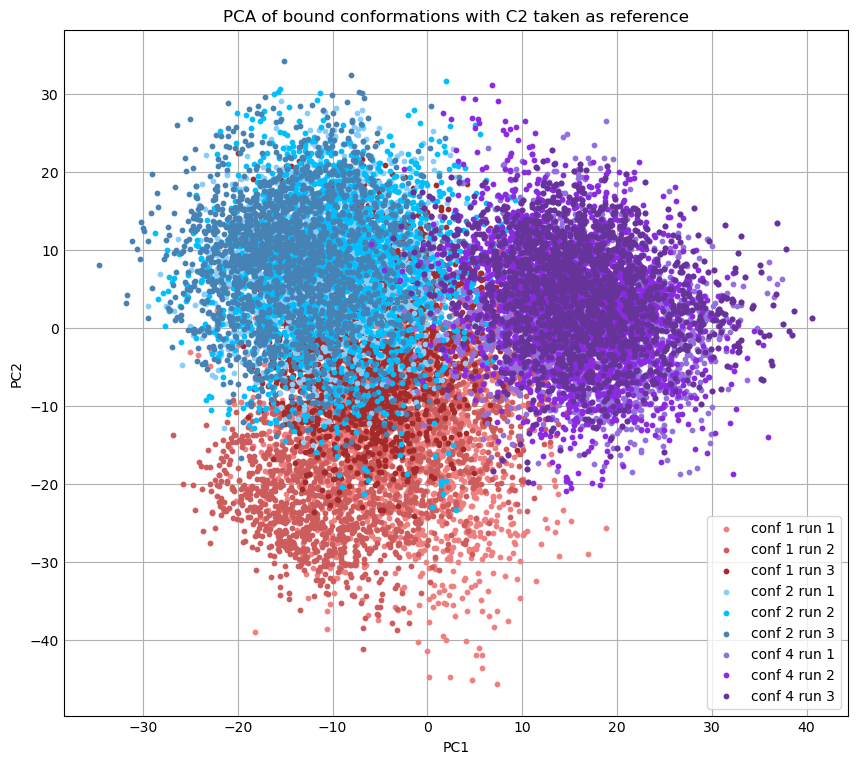

In [ ]:
plt.style.use('_mpl-gallery')
plt.figure(figsize=(8,7))
plt.scatter(dim_red_c[:2001,0],dim_red_c[:2001,1], s=10, color="lightcoral")
plt.scatter(dim_red_c[2001:4002,0],dim_red_c[2001:4002,1], s=10, color="indianred")
plt.scatter(dim_red_c[4002:6003,0],dim_red_c[4002:6003,1], s=10, color="brown")
plt.scatter(dim_red_c[6003:8004,0],dim_red_c[6003:8004,1], s=10, color="lightskyblue")
plt.scatter(dim_red_c[8004:10005,0],dim_red_c[8004:10005,1], s=10, color="deepskyblue")
plt.scatter(dim_red_c[10005:12006,0],dim_red_c[10005:12006,1], s=10, color="steelblue")
plt.scatter(dim_red_c[12006:14007,0],dim_red_c[12006:14007,1], s=10, color="mediumpurple")
plt.scatter(dim_red_c[14007:16008,0],dim_red_c[14007:16008,1], s=10, color="blueviolet")
plt.scatter(dim_red_c[16008:,0],dim_red_c[16008:,1], s=10, color="rebeccapurple")

plt.legend(['conf 1 run 1','conf 1 run 2', 'conf 1 run 3',
            'conf 2 run 1','conf 2 run 2', 'conf 2 run 3',
            'conf 4 run 1','conf 4 run 2', 'conf 4 run 3'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of bound conformations with C2 taken as reference')
plt.show()

## ALL plots together

In [ ]:
plt.style.use('_mpl-gallery')
plt.figure(figsize=(16,14))
plt.subplot(221)
plt.scatter(dim_red_h[:2001,0],dim_red_h[:2001,1], s=10, color="lightcoral")
plt.scatter(dim_red_h[2001:4002,0],dim_red_h[2001:4002,1], s=10, color="indianred")
plt.scatter(dim_red_h[4002:6003,0],dim_red_h[4002:6003,1], s=10, color="brown")
plt.scatter(dim_red_h[6003:8004,0],dim_red_h[6003:8004,1], s=10, color="lightskyblue")
plt.scatter(dim_red_h[8004:10005,0],dim_red_h[8004:10005,1], s=10, color="deepskyblue")
plt.scatter(dim_red_h[10005:12006,0],dim_red_h[10005:12006,1], s=10, color="steelblue")
plt.scatter(dim_red_h[12006:14007,0],dim_red_h[12006:14007,1], s=10, color="mediumpurple")
plt.scatter(dim_red_h[14007:,0],dim_red_h[14007:,1], s=10, color="blueviolet")
plt.scatter(dim_red_h[16008:,0],dim_red_h[16008:,1], s=10, color="rebeccapurple")
plt.legend(['conf 1 run 1','conf 1 run 2', 'conf 1 run 3',
            'conf 2 run 1','conf 2 run 2', 'conf 2 run 3',
            'conf 4 run 1','conf 4 run 2', 'conf 4 run 3'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of unbound conformations with heavy atoms taken as reference')

plt.subplot(222)
plt.scatter(dim_red_p[:2001,0],dim_red_p[:2001,1], s=10, color="lightcoral")
plt.scatter(dim_red_p[2001:4002,0],dim_red_p[2001:4002,1], s=10, color="indianred")
plt.scatter(dim_red_p[4002:6003,0],dim_red_p[4002:6003,1], s=10, color="brown")
plt.scatter(dim_red_p[6003:8004,0],dim_red_p[6003:8004,1], s=10, color="lightskyblue")
plt.scatter(dim_red_p[8004:10005,0],dim_red_p[8004:10005,1], s=10, color="deepskyblue")
plt.scatter(dim_red_p[10005:12006,0],dim_red_p[10005:12006,1], s=10, color="steelblue")
plt.scatter(dim_red_p[12006:14007,0],dim_red_p[12006:14007,1], s=10, color="mediumpurple")
plt.scatter(dim_red_p[14007:,0],dim_red_p[14007:,1], s=10, color="blueviolet")
plt.scatter(dim_red_p[16008:,0],dim_red_p[16008:,1], s=10, color="rebeccapurple")

plt.legend(['conf 1 run 1','conf 1 run 2', 'conf 1 run 3',
            'conf 2 run 1','conf 2 run 2', 'conf 2 run 3',
            'conf 4 run 1','conf 4 run 2', 'conf 4 run 3'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of unbound conformations with phosphates taken as reference')

plt.subplot(223)
plt.scatter(dim_red_c[:2001,0],dim_red_c[:2001,1], s=10, color="lightcoral")
plt.scatter(dim_red_c[2001:4002,0],dim_red_c[2001:4002,1], s=10, color="indianred")
plt.scatter(dim_red_c[4002:6003,0],dim_red_c[4002:6003,1], s=10, color="brown")
plt.scatter(dim_red_c[6003:8004,0],dim_red_c[6003:8004,1], s=10, color="lightskyblue")
plt.scatter(dim_red_c[8004:10005,0],dim_red_c[8004:10005,1], s=10, color="deepskyblue")
plt.scatter(dim_red_c[10005:12006,0],dim_red_c[10005:12006,1], s=10, color="steelblue")
plt.scatter(dim_red_c[12006:14007,0],dim_red_c[12006:14007,1], s=10, color="mediumpurple")
plt.scatter(dim_red_c[14007:,0],dim_red_c[14007:,1], s=10, color="blueviolet")
plt.scatter(dim_red_c[16008:,0],dim_red_c[16008:,1], s=10, color="rebeccapurple")
plt.legend(['conf 1 run 1','conf 1 run 2', 'conf 1 run 3',
            'conf 2 run 1','conf 2 run 2', 'conf 2 run 3',
            'conf 4 run 1','conf 4 run 2', 'conf 4 run 3'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of unbound conformations with C2 taken as reference')

plt.show()